# Win Factors and Match Outcome Analysis

Understanding what contributes to winning is one of the most important objectives in sports analytics.

While previous notebooks explored toss decisions, venue characteristics, and batting performance across different phases of an innings, this notebook focuses on identifying factors that are most commonly associated with match victories.

The objective is to move beyond descriptive analysis and investigate patterns that may help explain why teams win IPL matches.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [3]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

matches.replace(team_mapping, inplace=True)
deliveries.replace(team_mapping, inplace=True)

# Business Question 1

## How Important Is First Innings Score?

One of the most important strategic decisions in T20 cricket is determining a competitive first-innings total.

This analysis investigates whether higher first-innings scores are associated with a greater probability of winning matches.

In [5]:
first_innings = (
    deliveries[deliveries['inning'] == 1]
    .groupby('match_id')
    ['total_runs']
    .sum()
    .reset_index()
)

first_innings.columns = [
    'match_id',
    'first_innings_score'
]

first_innings.head()

,match_id,first_innings_score
0,335982,222
1,335983,240
2,335984,129
3,335985,165
4,335986,110


In [6]:
match_analysis = matches.merge(
    first_innings,
    left_on='id',
    right_on='match_id',
    how='inner'
)

match_analysis.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,match_id,first_innings_score
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,335982,222
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,335983,240
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,335984,129
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,...,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,335985,165
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,335986,110


In [7]:
match_analysis['score_band'] = pd.cut(
    match_analysis['first_innings_score'],
    bins=[0,140,160,180,200,300],
    labels=[
        'Below 140',
        '140-160',
        '160-180',
        '180-200',
        '200+'
    ]
)

In [8]:
match_analysis['score_band'].value_counts()

160-180      290
140-160      240
Below 140    223
180-200      204
200+         138
Name: score_band, dtype: int64

## First Innings Score Distribution

Before evaluating match outcomes, it is important to understand how first-innings scores are distributed across IPL matches.

Grouping scores into bands allows us to compare winning probabilities across different scoring ranges and identify whether higher totals provide a measurable advantage.

In [9]:
bat_first_wins = match_analysis[
    match_analysis['result'] == 'runs'
].groupby(
    'score_band'
).size()

In [10]:
total_matches_band = (
    match_analysis
    .groupby('score_band')
    .size()
)

In [11]:
score_band_analysis = pd.DataFrame({
    'Total_Matches': total_matches_band,
    'Bat_First_Wins': bat_first_wins
}).fillna(0)

In [12]:
score_band_analysis['Bat_First_Win_Percentage'] = (
    score_band_analysis['Bat_First_Wins']
    /
    score_band_analysis['Total_Matches']
    * 100
)

In [13]:
score_band_analysis

,Total_Matches,Bat_First_Wins,Bat_First_Win_Percentage
score_band,,,
Below 140,223,43,19.282511
140-160,240,72,30.000000
160-180,290,145,50.000000
180-200,204,124,60.784314
200+,138,114,82.608696


## Relationship Between First Innings Score and Match Outcomes

To understand the importance of first-innings scoring, matches were grouped into score bands and analyzed based on the percentage of victories achieved by the team batting first.

This approach helps identify score thresholds that significantly improve the probability of winning.

## Insight

The analysis reveals a strong relationship between first-innings score and winning probability.

Teams scoring below 140 runs won only 19.3% of matches when batting first, indicating that such totals are generally insufficient in the IPL.

The winning percentage increases steadily as scores rise:

- 140–160 runs: 30.0%
- 160–180 runs: 50.0%
- 180–200 runs: 60.8%
- 200+ runs: 82.6%

The results suggest that the 180-run mark represents an important scoring threshold, as teams crossing this level gain a clear advantage.

Additionally, teams posting 200 or more runs win more than four out of every five matches, making it one of the strongest indicators of success observed in the analysis.

These findings highlight that first-innings score has a substantially greater impact on match outcomes than winning the toss.

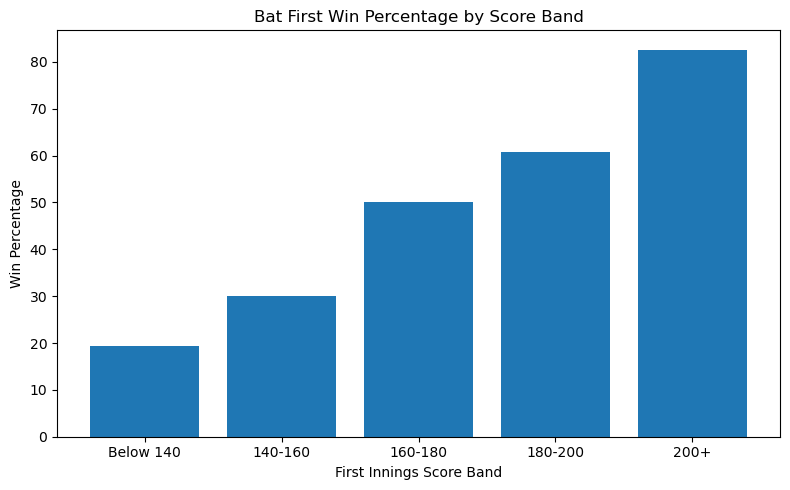

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    score_band_analysis.index.astype(str),
    score_band_analysis['Bat_First_Win_Percentage']
)

plt.title('Bat First Win Percentage by Score Band')
plt.xlabel('First Innings Score Band')
plt.ylabel('Win Percentage')

plt.tight_layout()
plt.show()

# Business Question 2

## What Score Should Be Considered A Competitive IPL Total?

While average scores provide useful context, teams often need a practical benchmark when deciding whether they have posted a defendable total.

This analysis investigates the average first-innings score in matches won by the team batting first and compares it with matches that were successfully chased.

In [16]:
bat_first_winners = match_analysis[
    match_analysis['result'] == 'runs'
]

chasing_winners = match_analysis[
    match_analysis['result'] == 'wickets'
]

In [17]:
bat_first_winners[
    'first_innings_score'
].describe()

count    498.000000
mean     179.973896
std       29.144152
min      106.000000
25%      162.000000
50%      178.000000
75%      197.750000
max      287.000000
Name: first_innings_score, dtype: float64

In [19]:
chasing_winners[
    'first_innings_score'
].describe()

count    578.000000
mean     153.546713
std       28.967837
min       67.000000
25%      135.250000
50%      155.000000
75%      174.000000
max      261.000000
Name: first_innings_score, dtype: float64

## Comparing Defendable and Chaseable Totals

To identify a practical benchmark for competitive scoring, first-innings totals were compared across two groups:

- Matches won by the team batting first.
- Matches won by the team chasing.

The objective is to determine whether successful defenses are associated with substantially higher scores.

## Insight

The average first-innings score in matches successfully defended was approximately 180 runs.

In contrast, matches won by chasing teams had an average first-innings score of approximately 154 runs.

This difference of more than 25 runs highlights the importance of posting a strong total when batting first.

Additional observations include:

- The median defended score was 178 runs.
- The median chased score was 155 runs.
- Teams defending totals typically scored between 162 and 198 runs (interquartile range).
- Teams successfully chasing generally faced targets between 135 and 174 runs.

The findings suggest that scores around 180 runs represent a strong and often defendable IPL total, while totals below 160 runs are significantly more vulnerable to successful chases.

# Business Question 3

## Does Powerplay Performance Influence Match Outcomes?

A strong start can provide momentum and create favorable conditions for the remainder of an innings.

This analysis investigates whether teams that score more runs during the powerplay are more likely to win matches.

In [20]:
powerplay_scores = (
    deliveries[
        deliveries['over'] <= 5
    ]
    .groupby(
        ['match_id', 'inning', 'batting_team']
    )['total_runs']
    .sum()
    .reset_index()
)

powerplay_scores.head()

,match_id,inning,batting_team,total_runs
0,335982,1,Kolkata Knight Riders,61
1,335982,2,Royal Challengers Bengaluru,26
2,335983,1,Chennai Super Kings,53
3,335983,2,Punjab Kings,63
4,335984,1,Rajasthan Royals,40


In [21]:
powerplay_match = matches.merge(
    powerplay_scores,
    left_on='id',
    right_on='match_id',
    how='inner'
)

powerplay_match.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,target_runs,target_overs,super_over,method,umpire1,umpire2,match_id,inning,batting_team,total_runs
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,335982,1,Kolkata Knight Riders,61
1,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,335982,2,Royal Challengers Bengaluru,26
2,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,241.0,20.0,N,NaN,MR Benson,SL Shastri,335983,1,Chennai Super Kings,53
3,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,241.0,20.0,N,NaN,MR Benson,SL Shastri,335983,2,Punjab Kings,63
4,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,335984,1,Rajasthan Royals,40


In [22]:
powerplay_match['won_match'] = (
    powerplay_match['batting_team']
    ==
    powerplay_match['winner']
)

In [23]:
powerplay_match.groupby(
    'won_match'
)['total_runs'].mean()

won_match
False    43.711331
True     49.420814
Name: total_runs, dtype: float64

## Powerplay Performance and Winning

To evaluate the impact of early-innings performance, average powerplay scores were compared between teams that won and teams that lost.

The objective is to determine whether stronger starts are associated with a higher probability of winning matches.

## Insight

Teams that won matches scored an average of 49.4 runs during the powerplay, compared to 43.7 runs for teams that lost.

This represents a difference of nearly 6 runs in the opening six overs.

The findings suggest that strong powerplay performance is associated with improved match outcomes. Early scoring allows teams to build momentum, create scoring opportunities for the middle overs, and reduce pressure on later batting phases.

While powerplay performance alone does not guarantee victory, the results indicate that successful teams generally establish stronger starts than their opponents.

# Business Question 4

## Does Losing Wickets In The Powerplay Affect Winning?

Aggressive batting during the powerplay can increase scoring opportunities, but it may also lead to early wicket losses.

This analysis evaluates whether teams that preserve wickets during the powerplay achieve better match outcomes than teams that lose wickets early.

In [24]:
powerplay_wickets = (
    deliveries[
        (deliveries['over'] <= 5)
        &
        (deliveries['is_wicket'] == 1)
    ]
    .groupby(
        ['match_id', 'inning', 'batting_team']
    )
    .size()
    .reset_index(name='powerplay_wickets')
)

powerplay_wickets.head()

,match_id,inning,batting_team,powerplay_wickets
0,335982,1,Kolkata Knight Riders,1
1,335982,2,Royal Challengers Bengaluru,4
2,335983,1,Chennai Super Kings,1
3,335983,2,Punjab Kings,1
4,335984,1,Rajasthan Royals,2


In [25]:
wicket_analysis = powerplay_match.merge(
    powerplay_wickets,
    on=['match_id', 'inning', 'batting_team'],
    how='left'
)

wicket_analysis['powerplay_wickets'] = (
    wicket_analysis['powerplay_wickets']
    .fillna(0)
)

In [26]:
wicket_analysis.groupby(
    'won_match'
)['powerplay_wickets'].mean()

won_match
False    1.750000
True     1.101357
Name: powerplay_wickets, dtype: float64

## Powerplay Wickets and Winning

Scoring quickly during the powerplay is important, but preserving wickets is equally valuable.

This analysis compares the average number of wickets lost during the powerplay by teams that won matches and teams that lost matches.

## Insight

Teams that won matches lost an average of 1.10 wickets during the powerplay, while teams that lost matches lost an average of 1.75 wickets.

This difference suggests that preserving wickets in the opening overs is strongly associated with successful match outcomes.

While aggressive batting can generate additional runs, excessive wicket losses may reduce batting depth and limit scoring opportunities later in the innings.

The findings indicate that successful IPL teams typically balance attacking intent with wicket preservation during the powerplay phase.

# Business Question 5

## Which Factor Appears More Important: Powerplay Runs or Powerplay Wickets?

Teams often face a trade-off between aggressive scoring and wicket preservation during the powerplay.

This analysis compares both factors to understand which appears to have a stronger relationship with winning matches.

In [27]:
win_factors = pd.DataFrame({
    'Metric': [
        'Powerplay Runs',
        'Powerplay Wickets Lost'
    ],
    'Winning Teams': [
        49.420814,
        1.101357
    ],
    'Losing Teams': [
        43.711331,
        1.750000
    ]
})

win_factors

,Metric,Winning Teams,Losing Teams
0,Powerplay Runs,49.420814,43.711331
1,Powerplay Wickets Lost,1.101357,1.750000


# Business Question 6

## Is 180 Runs A Winning Score In The IPL?

One of the most common questions in T20 cricket is whether a score of 180 runs can be considered a defendable total.

Using the score-band analysis, this section evaluates how winning probability changes as first-innings scores increase and identifies practical scoring thresholds for success.

In [31]:
score_band_analysis

,Total_Matches,Bat_First_Wins,Bat_First_Win_Percentage
score_band,,,
Below 140,223,43,19.282511
140-160,240,72,30.000000
160-180,290,145,50.000000
180-200,204,124,60.784314
200+,138,114,82.608696


## Insight

The relationship between first-innings score and winning probability is highly consistent.

Teams scoring below 140 runs won only 19.3% of matches when batting first.

The probability of victory increased steadily as scores increased:

- Below 140: 19.3%
- 140–160: 30.0%
- 160–180: 50.0%
- 180–200: 60.8%
- 200+: 82.6%

The analysis indicates that 180 runs represents a meaningful strategic threshold in the IPL.

Teams crossing the 180-run mark gain a clear statistical advantage, while teams scoring 200 or more win the vast majority of matches when batting first.

# Win Factors and Match Outcome Summary

This notebook examined several factors associated with IPL match victories and identified patterns that consistently differentiate winning teams from losing teams.

## Key Findings

### First Innings Score

- Teams scoring below 140 runs won only 19.3% of matches when batting first.
- Teams scoring 200 or more runs won approximately 82.6% of matches.
- The probability of winning increased consistently with higher first-innings totals.

### Powerplay Performance

- Winning teams averaged 49.4 runs during the powerplay.
- Losing teams averaged 43.7 runs.
- Strong starts were associated with improved match outcomes.

### Powerplay Wicket Preservation

- Winning teams lost an average of 1.10 wickets during the powerplay.
- Losing teams lost an average of 1.75 wickets.
- Preserving wickets early appears strongly associated with success.

## Overall Conclusion

The analysis suggests that first-innings score is the strongest indicator of match outcomes among the factors examined.

Successful teams typically combine:

- Strong powerplay scoring
- Effective wicket preservation
- Competitive first-innings totals

These findings highlight the importance of balancing aggression and risk management throughout the innings to maximize winning probability.